# 16. Single-forward negative component без masking

## Гипотеза из предыдущих наблюдений

Oracle clean→patched анализ показал две вещи: успешность определяется малой score/geometry-functional частью feature-delta, а причинный repair особенно эффективен для `top_negative` координат candidate reserve. Отсюда проверяется более сильная гипотеза: даже без clean-пары вредоносная часть может выделяться как **sparse отрицательный functional contribution относительно clean-population нормы**, согласованно подавляющий несколько кандидатов одного объекта.

Здесь полностью отсутствуют pixel masking, patch bbox и изменённые версии входного изображения. Независимые 100 clean-reference изображений задают только среднее каждого канала Detect-input. На 100 других изображениях из одного исходного forward вычисляется

`contribution = (activation - population_mean) * gradient(person-logit)`.

Затем выбранные отрицательные координаты заменяются population mean. Первый эксперимент использует oracle target reserve только для проверки сигнатуры; второй самостоятельно строит candidate clusters из attacked forward и ранжирует их по предсказанному отрицательному gain. Clean target/bbox используются только после вмешательства для evaluation.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
ROOT=Path.cwd()
if ROOT.name!='CandidateRoutingAndAttackPath': ROOT=ROOT/'CandidateRoutingAndAttackPath'
def latest(prefix):
    found=[]
    for d in (ROOT/'followup_outputs').glob(prefix+'_*'):
        if (d/'summary.json').exists():
            s=json.loads((d/'summary.json').read_text()); found.append((s['config'].get('method_version',0),d,s))
    return max(found,key=lambda z:z[0])[1:]
SIG,SIG_SUM=latest('single_forward_component')
AUTO,AUTO_SUM=latest('autonomous_negative_repair')
S=pd.read_csv(SIG/'single_forward_rows.csv')
A=pd.read_csv(AUTO/'autonomous_repair_rows.csv')
CL=pd.read_csv(AUTO/'autonomous_cluster_rows.csv')
print('signature:',SIG.name,'| autonomous:',AUTO.name)

signature: single_forward_component_55ef1d53e069f109 | autonomous: autonomous_negative_repair_2434fc351b83dc49


,condition,hidden recovery,clean target preserved,oracle cosine,residual energy
0,observed,0.0000,1.0,NaN,NaN
1,negative_sum_modes,0.1020,1.0,0.1687,0.0002
2,negative_consensus_modes,0.0000,1.0,0.2937,0.0000
3,full_score_rowspace,0.0000,1.0,-0.4345,0.0034
4,top_negative_50,0.2041,1.0,0.1270,0.0106
5,top_negative_100,0.2245,1.0,0.1269,0.0196
6,top_negative_250,0.4286,1.0,0.1266,0.0380
7,top_negative_500,0.4694,1.0,0.1251,0.0593


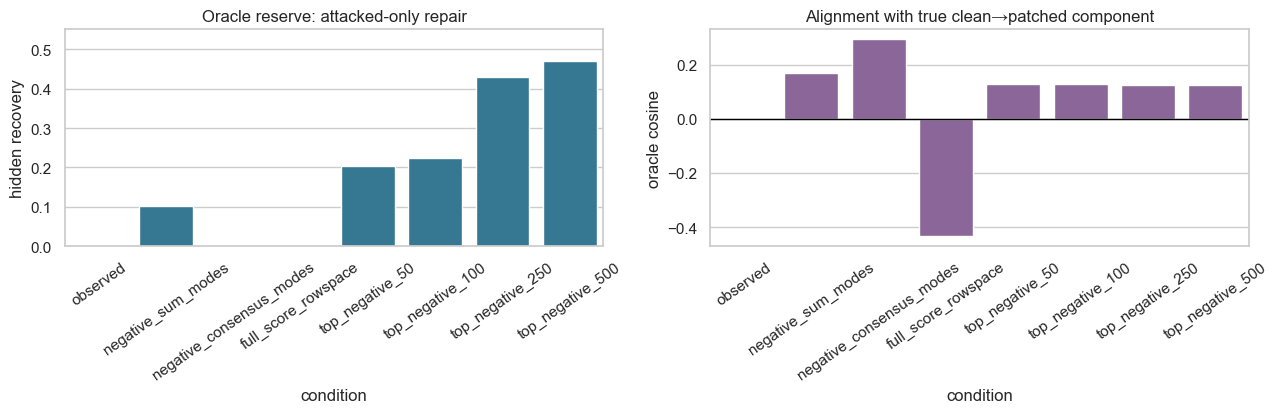

In [2]:
sp=S[(S.input_kind=='patched') & (S.source_hidden==1)]
sc=S[S.input_kind=='clean']
conditions=['observed','negative_sum_modes','negative_consensus_modes','full_score_rowspace','top_negative_50','top_negative_100','top_negative_250','top_negative_500']
rows=[]
for condition in conditions:
    hp=sp[sp.condition==condition]; cc=sc[sc.condition==condition]
    cosine_col=f'{condition}_oracle_cosine'
    energy_col=f'{condition}_residual_energy_fraction'
    rows.append({'condition':condition,'hidden recovery':hp.target_detected.mean(),'clean target preserved':cc.target_detected.mean(),
                 'oracle cosine':hp[cosine_col].mean() if cosine_col in hp else np.nan,
                 'residual energy':hp[energy_col].mean() if energy_col in hp else np.nan})
signature=pd.DataFrame(rows); display(signature.round(4))
fig,axes=plt.subplots(1,2,figsize=(13,4.3))
sns.barplot(data=signature,x='condition',y='hidden recovery',ax=axes[0],color='#277da1'); axes[0].tick_params(axis='x',rotation=35); axes[0].set_ylim(0,.55); axes[0].set_title('Oracle reserve: attacked-only repair')
sns.barplot(data=signature,x='condition',y='oracle cosine',ax=axes[1],color='#8e5ea2'); axes[1].tick_params(axis='x',rotation=35); axes[1].axhline(0,color='black',lw=1); axes[1].set_title('Alignment with true clean→patched component')
plt.tight_layout(); plt.show()

**Что видно.** Полная проекция population residual в score-rowspace имеет отрицательный cosine с oracle и не восстанавливает ни одного hidden target: она смешивает вредоносное подавление с нормальным semantic signal. SVD-моды с отрицательным средним эффектом дают только 5/49 recovery, строгие consensus-моды — 0/49. Зато sparse coordinate-level `top_negative` монотонно растёт до 23/49 при `k=500`, сохраняя 100/100 clean-target. Средний cosine около 0.13 невелик: это не точное восстановление oracle-вектора, а частично совпадающая функциональная замена. Следовательно, компонент выделяется знаком отдельных contributions, но не как простая глобальная low-rank аномалия.

,condition,hidden recovery,target cluster selected,clean target preserved,clean full-output F1,hidden full-output F1
0,observed,0.0000,0.6531,1.0,1.0000,0.0514
1,top1_k250,0.2857,0.6531,1.0,0.9676,0.1495
2,top1_k500,0.3673,0.6531,1.0,0.9583,0.1558
3,top1_k1000,0.4490,0.6531,1.0,0.9526,0.1751
4,top2_k500,0.4082,0.7551,1.0,0.9505,0.1427


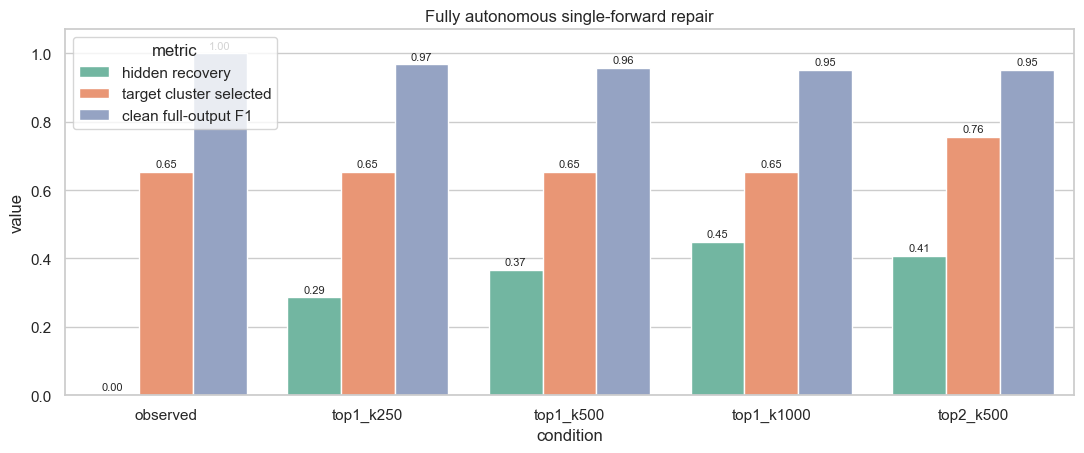

In [3]:
ap=A[(A.input_kind=='patched') & (A.source_hidden==1)]
ac=A[A.input_kind=='clean']
rows=[]
for condition in A.condition.unique():
    hp=ap[ap.condition==condition]; cc=ac[ac.condition==condition]
    rows.append({'condition':condition,'hidden recovery':hp.target_detected.mean(),
                 'target cluster selected':hp.selected_contains_target_cluster.mean(),
                 'clean target preserved':cc.target_detected.mean(),
                 'clean full-output F1':cc.detection_detection_f1.mean(),
                 'hidden full-output F1':hp.detection_detection_f1.mean()})
autonomous=pd.DataFrame(rows); display(autonomous.round(4))
plot=autonomous.melt('condition',value_vars=['hidden recovery','target cluster selected','clean full-output F1'],var_name='metric',value_name='value')
plt.figure(figsize=(11,4.7)); ax=sns.barplot(data=plot,x='condition',y='value',hue='metric',palette='Set2')
for c in ax.containers: ax.bar_label(c,fmt='%.2f',padding=2,fontsize=8)
ax.set_ylim(0,1.07); plt.title('Fully autonomous single-forward repair'); plt.tight_layout(); plt.show()

**Что видно.** Без oracle reserve лучший `top1_k1000` восстанавливает 22/49 hidden target. Ranking выбирает target-cluster первым в 32/49 случаев; при правильном выборе repair успешен в 22/32, при неправильном — 0/17. Два лучших кластера покрывают target в 37/49, но разделение бюджета (`top2_k500`) даёт лишь 20/49. Значит, текущие два bottleneck независимы: shortlist/ranking теряет 17 случаев, а population-mean estimate недостаточно точен ещё в 10 правильно локализованных.

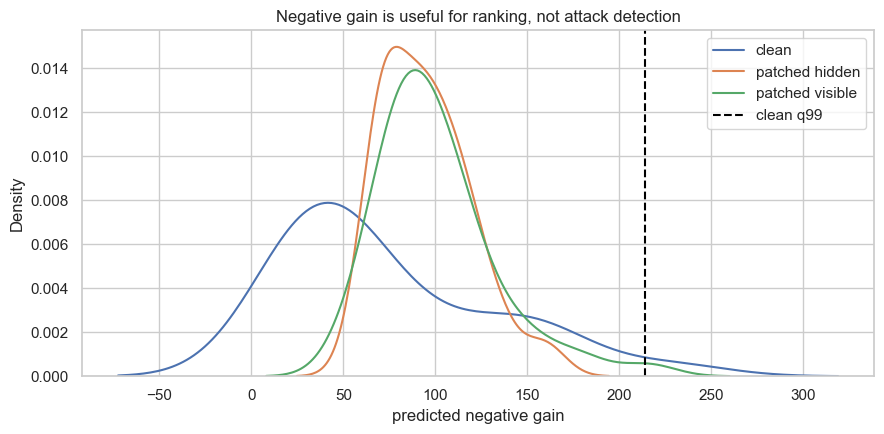

clean q99 = 214.151 | hidden above q99 = 0.0


In [4]:
chosen=A[(A.input_kind=='patched') & (A.condition=='observed')]
clean_gain=A[(A.input_kind=='clean') & (A.condition=='observed')].chosen_predicted_gain
hidden_gain=chosen[chosen.source_hidden==1].chosen_predicted_gain
visible_gain=chosen[chosen.source_hidden==0].chosen_predicted_gain
plt.figure(figsize=(9,4.5));
for values,label in [(clean_gain,'clean'),(hidden_gain,'patched hidden'),(visible_gain,'patched visible')]: sns.kdeplot(values,label=label,fill=False)
plt.axvline(clean_gain.quantile(.99),color='black',ls='--',label='clean q99'); plt.xlabel('predicted negative gain'); plt.title('Negative gain is useful for ranking, not attack detection'); plt.legend(); plt.tight_layout(); plt.show()
print('clean q99 =',round(clean_gain.quantile(.99),3),'| hidden above q99 =',round((hidden_gain>clean_gain.quantile(.99)).mean(),3))

**Отрицательный результат.** Magnitude predicted gain ранжирует кластеры внутри изображения, но не определяет наличие атаки между изображениями: clean имеет тяжёлые outliers, а ни один hidden пример не превышает clean `q99`. Поэтому отдельный gate на этой величине не оправдан.

Постоянное вмешательство тоже пока не достаточно безопасно: `k=250` даёт clean full-output F1 0.968 при 14/49 recovery; `k=1000` повышает recovery до 22/49, но снижает clean F1 до 0.953. При этом clean target сохраняется 25/25 для всех бюджетов — вред приходится на другие детекции.

## Итог и следующий шаг

Новая часть действительно использует наши наблюдения, а не masking:

- candidate reserve задаёт объект как несколько конкурирующих маршрутов;
- `top_negative` переносится с paired clean-delta на отклонение от независимой clean-population нормы;
- исправляется sparse набор из 250–1000 внутренних координат одного forward;
- patch location и altered image не используются.

Результат подтверждает существование single-forward сигнала, но текущая оценка компоненты неполна. Следующие наиболее обоснованные тесты:

1. заменить грубый channel mean на conditional clean predictor активаций по соседнему feature-context; это должно уменьшить 10 ошибок после правильной локализации и clean harm;
2. добавить в ranking ранний person-evidence / score-drop inconsistency, чтобы target reserve попадал на первое место чаще 32/49;
3. при выборе координат добавить preservation constraint для logits остальных устойчивых кластеров, потому что clean full-output портится при сохранении target;
4. после фиксации метода расширить clean evaluation и varied-location attacks.

Наиболее прямой следующий эксперимент — **context-conditioned internal baseline + protected-cluster constraint**. Он сохраняет attacked-only постановку и адресует обе наблюдаемые ошибки, не возвращаясь к masking.